# 08 - EDA e reducao de features MACE

Etapa 3, Fase A.5. EDA das features MACE-MP-0, importancia (SHAP / permutation / RFE) e estrategias de reducao.

Nota de escopo: a Tarefa 2 extraiu **7 features escalares** (energias per-atom do MACE); embeddings de no foram adiados. Logo a razao amostras/features e ~670 (nao os ~15 perigosos que motivariam reducao agressiva). Esta EDA decide se vale extrair embeddings (Fase B) ou se os escalares ja bastam.

Logica em `src/her_gnn/analysis`; o notebook orquestra e visualiza.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(ROOT)

from her_gnn.analysis.feature_eda import (
    as_frame, correlation_matrix, load_split, load_xy, near_zero_variance,
    plot_distributions, plot_target_correlation, redundant_pairs, target_correlation,
)
from her_gnn.analysis.feature_importance import (
    fit_etr, pareto_count, permutation_ranking, rfecv_select, shap_bar, shap_beeswarm,
    shap_importance,
)

X_train, y_train, X_test, y_test, names = load_xy()
df = as_frame(load_split("train"))
print(f"train={X_train.shape} test={X_test.shape}  features={names}")

train=(4688, 7) test=(1172, 7)  features=['mace_E_total', 'mace_E_per_atom', 'mace_E_H', 'mace_E_neighbors_mean', 'mace_E_neighbors_min', 'mace_E_surface_mean', 'mace_n_neighbors']


## 1.1 Distribuicoes

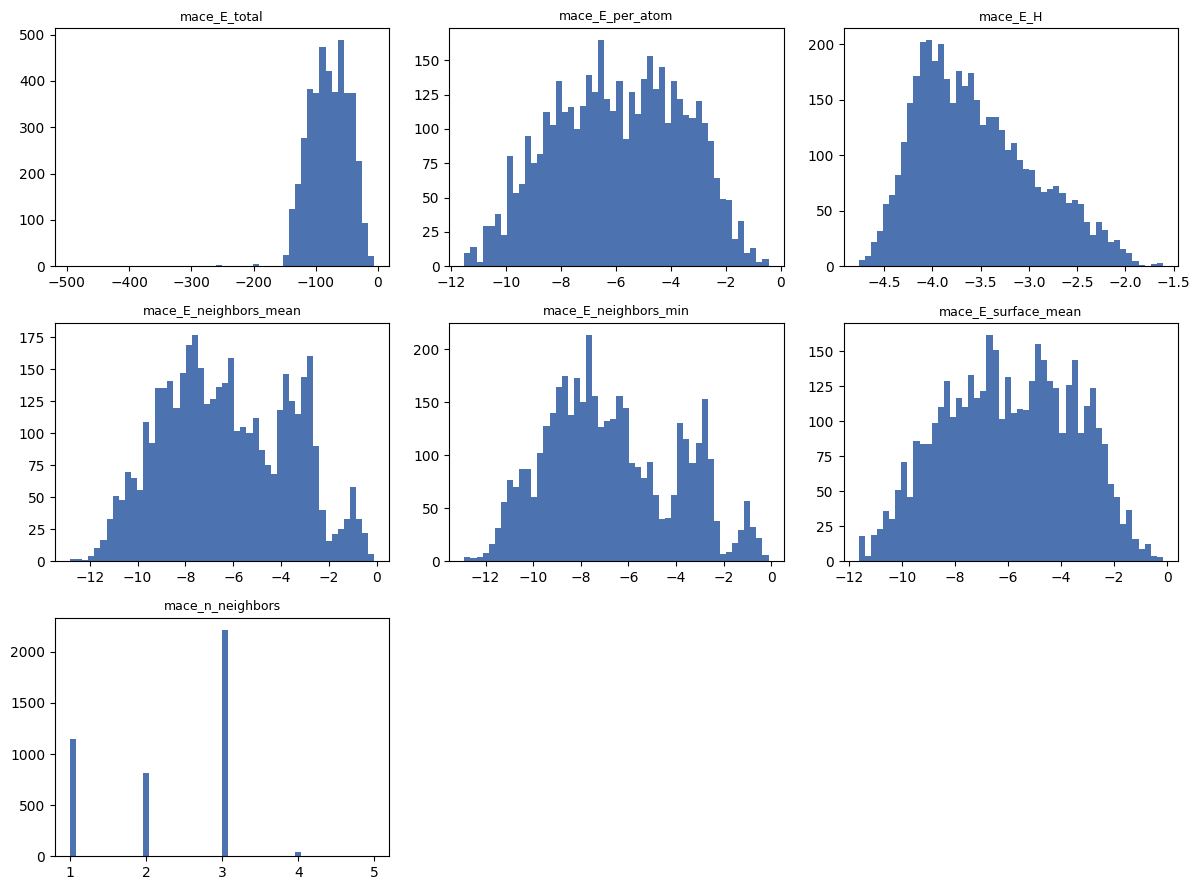

variancia ~0: []


In [2]:
plot_distributions(df, names)
plt.show()
print("variancia ~0:", near_zero_variance(df, names))

## 1.2 Correlacao de Pearson (analogia a Fig. S5 do paper, espaco MACE)

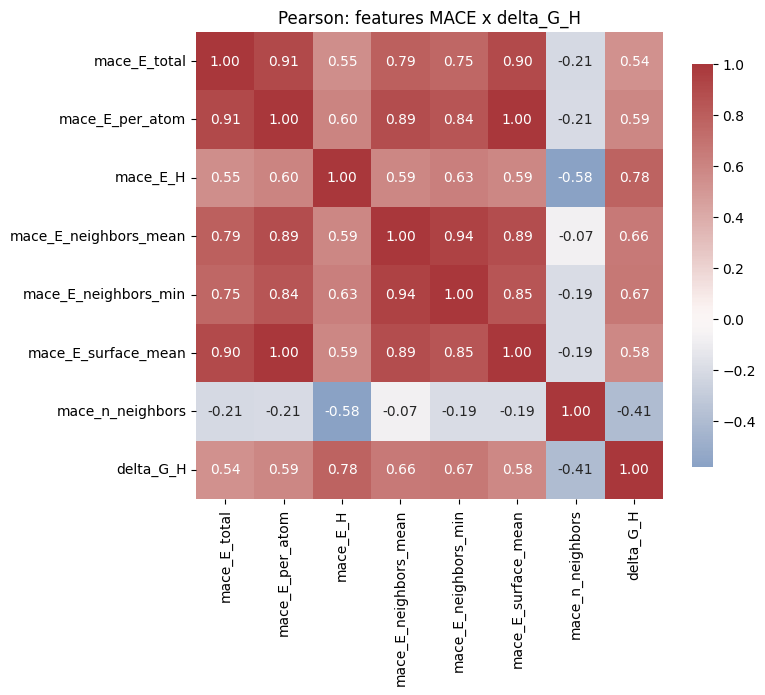

pares |rho|>0.95 (redundantes):
  mace_E_per_atom ~ mace_E_surface_mean: 0.998


In [3]:
fig, corr = correlation_matrix(df, names)
plt.show()
print("pares |rho|>0.95 (redundantes):")
for a, b, r in redundant_pairs(corr, names):
    print(f"  {a} ~ {b}: {r}")

## 1.3 Correlacao feature x ΔG_H

Paper: Nd0 tem |ρ| ~0.4 com o alvo. Alguma feature MACE chega perto?

mace_E_H                 0.776586
mace_E_neighbors_min     0.667284
mace_E_neighbors_mean    0.655255
mace_E_per_atom          0.588748
mace_E_surface_mean      0.583814
mace_E_total             0.536960
mace_n_neighbors         0.405497


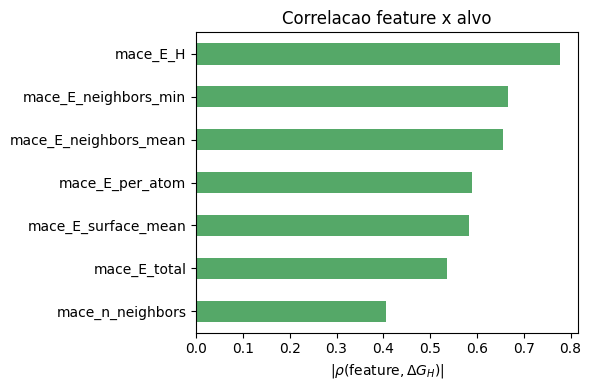

In [4]:
corr_y = target_correlation(df, names)
print(corr_y.to_string())
plot_target_correlation(corr_y)
plt.show()

## 2.1 SHAP em ETR full

mace_E_H                 0.227384
mace_E_neighbors_mean    0.153114
mace_E_neighbors_min     0.144566
mace_n_neighbors         0.061091
mace_E_per_atom          0.022965
mace_E_surface_mean      0.021704
mace_E_total             0.014826

features p/ 90% da importancia (Pareto): 4


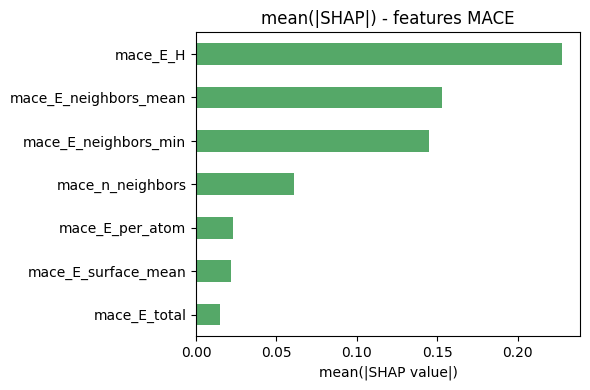

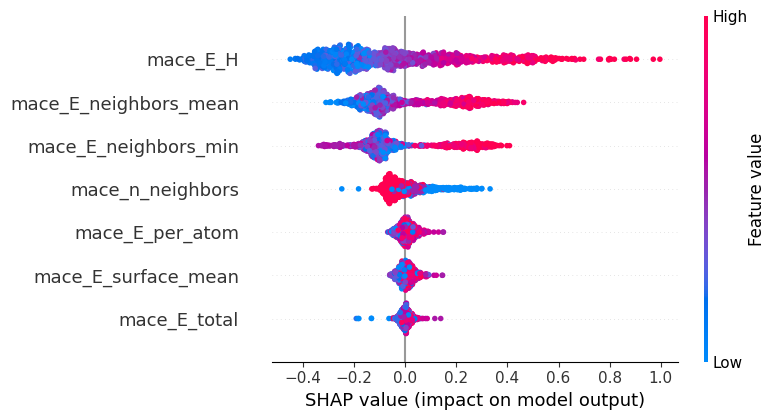

In [5]:
model = fit_etr(X_train, y_train)
ranking, shap_values = shap_importance(model, X_test, names)
print(ranking.to_string())
print(f"\nfeatures p/ 90% da importancia (Pareto): {pareto_count(ranking)}")
shap_bar(ranking, title="mean(|SHAP|) - features MACE")
plt.show()
shap_beeswarm(shap_values, X_test, names)
plt.show()

## 2.2 Permutation importance (sanity check independente)

In [6]:
perm = permutation_ranking(model, X_test, y_test, names)
print(perm.to_string())
print("\nmesma ordem do top-3 que o SHAP?",
      list(perm.index[:3]) == list(ranking.index[:3]))

mace_E_H                 0.526367
mace_E_neighbors_mean    0.365804
mace_E_neighbors_min     0.272004
mace_n_neighbors         0.095746
mace_E_surface_mean      0.025988
mace_E_per_atom          0.021044
mace_E_total             0.014099

mesma ordem do top-3 que o SHAP? True


## 2.3 RFECV

In [7]:
n_opt, selected = rfecv_select(X_train, y_train, names)
print(f"RFECV otimo: {n_opt} features -> {selected}")

RFECV otimo: 7 features -> ['mace_E_total', 'mace_E_per_atom', 'mace_E_H', 'mace_E_neighbors_mean', 'mace_E_neighbors_min', 'mace_E_surface_mean', 'mace_n_neighbors']


## 3. Sweep de reducao

Rodar `uv run python scripts/08b_feature_reduction_sweep.py` gera os runs e o grafico abaixo (R² test vs # features, com baselines ETR=0.934 e SchNet=0.908).

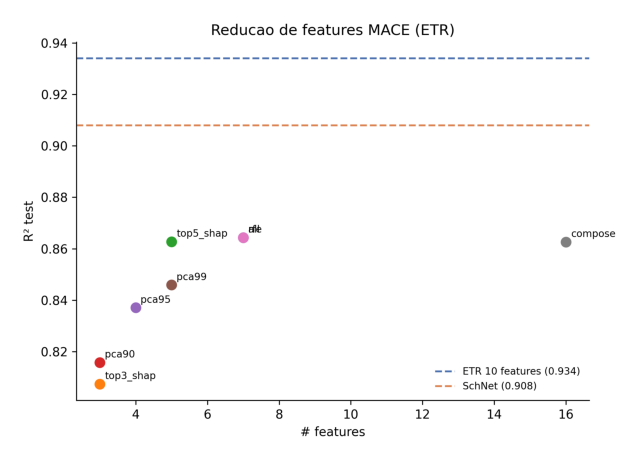

In [8]:
sweep_png = Path("results/figures/feature_reduction_sweep.png")
if sweep_png.exists():
    from matplotlib import image as mpimg
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(mpimg.imread(sweep_png))
    ax.set_axis_off()
    plt.show()
else:
    print("rode scripts/08b_feature_reduction_sweep.py primeiro")

## 5. Validacao no MLP

Confirma que o achado (poucas features bastam) nao e especifico ao ETR.

In [9]:
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from her_gnn.analysis.feature_reduction import select, top_k

def mlp_r2(cols):
    Xtr = select(X_train, names, cols) if cols else X_train
    Xte = select(X_test, names, cols) if cols else X_test
    mlp = make_pipeline(StandardScaler(),
                        MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=2000,
                                     random_state=42, early_stopping=True))
    mlp.fit(Xtr, y_train)
    return r2_score(y_test, mlp.predict(Xte))

for label, cols in [("all", names), ("top5", top_k(ranking, 5)), ("top3", top_k(ranking, 3))]:
    print(f"MLP {label} ({len(cols)} feats): R2={mlp_r2(cols):.4f}")

MLP all (7 feats): R2=0.8124


MLP top5 (5 feats): R2=0.8168


MLP top3 (3 feats): R2=0.7832
